# Advanced: Adjust simulation to ERA5 Atmospheric Profiles

Integration of ERA5 reanalysis data for realistic atmospheric profile input to radiative transfer simulations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import gcsfs
import os
#!pip install cfgrib
import cfgrib

In [2]:
kiruna_lat, kiruna_lon = 67.84889, 20.3027

In [ ]:
# import numpy as np
# import xarray as xr
# import pandas as pd

# ds_carra = xr.open_dataset('/projekt_agmwend/data_raw/COMPEX-EC/04_ERA5/CARRA_pressure_levels/CARRA_COMPEX-EC_pressure_levels.grib', engine='cfgrib', chunks={'x': 100, 'y': 100})
# carra_lat = ds_carra['latitude'].load()
# carra_lon = ds_carra['longitude'].load()
# def _wrap_lon_rad(dlon_rad):
#     two_pi = 2.0 * np.pi
#     return (dlon_rad + np.pi) % two_pi - np.pi

# def nearest_carra_point(carra_lat, carra_lon, lat0_deg, lon0_deg):
#     """
#     carra_lat, carra_lon: xarray.DataArray with dims ('y','x'), in degrees
#     lat0_deg, lon0_deg: scalars in degrees
#     Returns: dict with label indices (iy, ix), positional indices (iy_pos, ix_pos), and coordinates.
#     """
#     # radians (Dask-safe)
#     lat_r = xr.apply_ufunc(np.deg2rad, carra_lat)
#     lon_r = xr.apply_ufunc(np.deg2rad, carra_lon)
#     lat0_r = float(np.deg2rad(lat0_deg))
#     lon0_r = float(np.deg2rad(lon0_deg))

#     dlat = lat_r - lat0_r
#     dlon = _wrap_lon_rad(lon_r - lon0_r)

#     a = xr.apply_ufunc(np.sin, dlat/2)**2 + np.cos(lat0_r) * xr.apply_ufunc(np.cos, lat_r) * xr.apply_ufunc(np.sin, dlon/2)**2

#     # stack -> argmin along stacked dim
#     z = a.stack(z=("y", "x"))
#     k = z.argmin("z").item()  # compute small scalar

#     # Convert the stacked coordinate to a pandas.MultiIndex, then index into it
#     mi = z["z"].to_index()          # pandas.MultiIndex
#     iy_label, ix_label = mi[k]      # labels along 'y' and 'x'

#     # Fetch values via label-based selection (still Dask-friendly; .item() pulls just 2 scalars)
#     closest_lat = carra_lat.sel(y=iy_label, x=ix_label).item()
#     closest_lon = carra_lon.sel(y=iy_label, x=ix_label).item()

#     # Get positional indices robustly (works whether or not coords are “real” Index objects)
#     try:
#         y_index = carra_lat.get_index("y")  # xarray >=0.20
#     except Exception:
#         # fallback to pandas Index from the coord values
#         y_index = pd.Index(carra_lat["y"].values)
#     try:
#         x_index = carra_lat.get_index("x")
#     except Exception:
#         x_index = pd.Index(carra_lat["x"].values)

#     iy_pos = int(y_index.get_loc(iy_label))
#     ix_pos = int(x_index.get_loc(ix_label))

#     return {
#         "iy": iy_label, "ix": ix_label,
#         "iy_pos": iy_pos, "ix_pos": ix_pos,
#         "lat": closest_lat, "lon": closest_lon
#     }

# # --- usage ---
# out = nearest_carra_point(carra_lat, carra_lon, kiruna_lat, kiruna_lon)
# print(f"Kiruna: ({kiruna_lat:.6f}, {kiruna_lon:.6f})")
# print(f"Closest CARRA grid point: ({out['lat']:.6f}, {out['lon']:.6f})")
# print(f"Indices (labels): y={out['iy']}, x={out['ix']}")
# print(f"Indices (pos):    y={out['iy_pos']}, x={out['ix_pos']}")

# ds_kiruna = ds_carra.isel(x=out['ix_pos'], y=out['iy_pos'])
# carra wtihout regridding

# # ---- Dask cluster: 16 workers, 200 GB total RAM, dashboard on :8787 ----
# from dask.distributed import LocalCluster, Client
# import os, pathlib

# # Put worker spill space on a fast local disk (NVMe if you have it)
# tmp = "/projekt_agmwend/home_rad/Joshua/dask-tmp"  # change to a fast local path you own
# pathlib.Path(tmp).mkdir(parents=True, exist_ok=True)

# # 200 GB / 16 workers = 12.5 GB per worker hard cap
# cluster = LocalCluster(
#     n_workers=4,
#     threads_per_worker=1,          # avoid GIL contention; good for I/O + HDF5
#     processes=True,
#     memory_limit="100GB",
#     dashboard_address=":8787",     # open http://<host>:8787
#     #local_directory=tmp,           # worker temp / spill
# )

# client = Client(cluster)
# client

# from rechunker import rechunk
# import shutil
# import xarray as xr, fsspec

# src_path  = "/projekt_agmwend/data_raw/COMPEX-EC/04_ERA5/CARRA_pressure_levels/CARRA_EAST_latlon0p05.nc"
tgt_store = "/projekt_agmwend/data_raw/COMPEX-EC/04_ERA5/CARRA_pressure_levels/CARRA_point_optimized.zarr"
# tmp_store = "/projekt_agmwend/data_raw/COMPEX-EC/04_ERA5/CARRA_pressure_levels/tmp"
# shutil.rmtree(tgt_store, ignore_errors=True)
# shutil.rmtree(tmp_store,  ignore_errors=True)

# ds = xr.open_dataset(src_path, chunks='auto')  # inherit on-disk chunks

# # Rechunk only the 4D fields; give explicit tuples so rechunker can’t mis-infer
# vars4d = [v for v in ds.data_vars if ds[v].ndim == 4]
# per_var_chunks = {v: (ds.sizes["time"], ds.sizes["plev"], 10, 10) for v in vars4d}  # (time, plev, lat, lon)

# plan = rechunk(
#     source=ds[vars4d],
#     target_chunks=per_var_chunks,
#     max_mem="64GB",  # working buffer for the PIPELINE, not total RAM
#     target_store=fsspec.get_mapper(tgt_store),
#     temp_store=fsspec.get_mapper(tmp_store),
#     executor="dask",  # <-- IMPORTANT: runs on your cluster, visible in the dashboard
# )
# plan.execute()

# # Write coords once (cheap) so the Zarr is self-contained
# ds[["time","plev","latitude","longitude"]].to_zarr(tgt_store, mode="r+")


In [4]:
ds_kiruna_regridded = xr.open_dataset('/projekt_agmwend/data_raw/COMPEX-EC/04_ERA5/CARRA_pressure_levels/CARRA_EAST_latlon0p05.nc', chunks='auto').rename({'lat' : 'latitude', 'lon': 'longitude'})

/projekt_agmwend/home_rad/Joshua/micromamba/envs/mamba_josh/lib/python3.12/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'gini' loading failed:
module 'numpy' has no attribute 'cumproduct'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


In [22]:
ds_kiruna_optimized = xr.open_dataset(tgt_store)
ds_kiruna = ds_kiruna_optimized.sel(lat=kiruna_lat, lon=kiruna_lon, method='nearest').load()
ds_kiruna.r.units

ds_kiruna_to_sim = ds_kiruna
ds_kiruna_to_sim = ds_kiruna_to_sim.rename({'r': 'q', 
                                            'plev': 'pressure_level',
                                            'lon' : 'longitude',
                                            'lat' : 'latitude',
                                            'time' : 'valid_time'})  # pyradtran expects 'q' for specific humidity
ds_kiruna_to_sim['pressure_level'].attrs['units'] = 'Pa'  # change unit from Pa to hPa

/projekt_agmwend/home_rad/Joshua/tmp/ipykernel_2587918/225016988.py:1: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  ds_kiruna_optimized = xr.open_dataset(tgt_store)


In [23]:
ds_kiruna_to_sim.pressure_level.units

'Pa'

In [24]:
from pyradtran.io import ERA5AtmosphereGenerator

atmosphere = ERA5AtmosphereGenerator()
atmosphere.create_era5_atmosphere_file(
    ds_kiruna_to_sim,
    latitude=kiruna_lat,
    
    longitude=kiruna_lon,
    time=ds_kiruna_to_sim.valid_time.values[0],
    output_filepath='work/test.atm'
)

PosixPath('work/test.atm')

ds_kiruna.clwc.plot(x='time', yincrease=False)
plt.yscale('log')

In [14]:
# Import PyRadtran components using NEW IO system
from pyradtran.interface import PyRadtranAccessor  # This should register the accessor automatically
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import pandas as pd

# Load the configuration from the YAML file
config_path = Path('../config/thermal_config.yaml')
import logging
# change to "DEBUG" if you want to see more output
logging.getLogger('pyradtran').setLevel(logging.DEBUG)

# stationary simulation at constant altitude, latitude, and longitude but with varying time
# be aware that the max altitude needs to be lower than the max altitude in the ERA5 data

N_timesteps = ds_kiruna.dims['time']

ds = xr.Dataset(
    coords={
        'time' : ds_kiruna['time'],
        'latitude' : ('time', [kiruna_lat] * N_timesteps),
        'longitude' : ('time', [kiruna_lon] * N_timesteps),
        'altitude' : ('altitude', np.arange(0, 20, 1)),
    }
)

# ds_kiruna_to_sim = ds_kiruna
# ds_kiruna_to_sim['q'] = ds_kiruna_to_sim['r']
# ds_kiruna_to_sim['pressure_level'] = ds_kiruna_to_sim['isobaricInhPa']
# ds_kiruna_to_sim = ds_kiruna_to_sim.assign_coords(pressure_level=ds_kiruna_to_sim['isobaricInhPa'])

/projekt_agmwend/home_rad/Joshua/tmp/ipykernel_2425437/620041066.py:18: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  N_timesteps = ds_kiruna.dims['time']


In [15]:
ds_kiruna_to_sim

<xarray.Dataset> Size: 176kB
Dimensions:         (valid_time: 136, pressure_level: 23)
Coordinates:
    latitude        float64 8B 67.85
    longitude       float64 8B 20.3
  * pressure_level  (pressure_level) float64 184B 1e+03 2e+03 ... 9.5e+04 1e+05
  * valid_time      (valid_time) datetime64[ns] 1kB 2025-04-01 ... 2025-04-17...
Data variables: (12/14)
    ccl             (valid_time, pressure_level) float32 13kB 0.0 0.0 ... 0.0
    ciwc            (valid_time, pressure_level) float32 13kB 0.0 0.0 ... 0.0
    clwc            (valid_time, pressure_level) float32 13kB 0.0 0.0 ... 0.0
    crwc            (valid_time, pressure_level) float32 13kB -1.175e-38 ... ...
    cswc            (valid_time, pressure_level) float32 13kB -1.175e-38 ... ...
    grle            (valid_time, pressure_level) float32 13kB -1.175e-38 ... ...
    ...              ...
    q               (valid_time, pressure_level) float32 13kB 0.09165 ... 89.07
    t               (valid_time, pressure_level) float32 13kB 219.0 ... 282.8
    u               (valid_time, pressure_level) float32 13kB -11.75 ... 0.133
    v               (valid_time, pressure_level) float32 13kB -15.17 ... 1.269
    wz              (valid_time, pressure_level) float32 13kB 0.03421 ... -0....
    z               (valid_time, pressure_level) float32 13kB 3.01e+05 ... 684.3
Attributes:
    CDI:                       Climate Data Interface version 2.2.4 (https://...
    CDO:                       Climate Data Operators version 2.2.2 (https://...
    Conventions:               CF-1.6
    cdo_openmp_thread_number:  8
    history:                   Mon Sep 01 13:26:47 2025: cdo -P 8 -f nc4c -z ...

In [16]:
ds_sim = ds.pyradtran.run(
    config_path=config_path,
    return_dataset=True,
    save_to_file=False,
    era5_atmosphere=ds_kiruna_to_sim,  # Use the local ERA5 data
)

2025-09-01 16:54:10,951 - pyradtran.config - WARNING - Ignoring unknown config parameter: variable_encoding in OutputConfig
2025-09-01 16:54:10,959 - pyradtran.config - WARNING - Ignoring unknown config parameter: aerosol_type in SimulationDefaults
2025-09-01 16:54:10,960 - pyradtran.config - WARNING - Ignoring unknown config parameter: aerosols in SimulationDefaults
2025-09-01 16:54:10,961 - pyradtran.config - WARNING - Ignoring unknown config parameter: albedo_file in SimulationDefaults
2025-09-01 16:54:10,962 - pyradtran.config - WARNING - Ignoring unknown config parameter: albedo_library in SimulationDefaults
2025-09-01 16:54:10,962 - pyradtran.config - WARNING - Ignoring unknown config parameter: albedo_type in SimulationDefaults
2025-09-01 16:54:10,963 - pyradtran.config - WARNING - Ignoring unknown config parameter: brdf_cam in SimulationDefaults
2025-09-01 16:54:10,963 - pyradtran.config - WARNING - Ignoring unknown config parameter: brdf_rpv in SimulationDefaults
2025-09-01 16

2025-09-01 16:54:11,002 - pyradtran.interface - DEBUG - Created ERA5 atmosphere file for 20250401_060000_67.85_20.30: work/era5_atmospheres/era5_atm_20250401_060000_67.85_20.30.dat
2025-09-01 16:54:11,011 - pyradtran.io - INFO - Created ERA5 atmosphere file: work/era5_atmospheres/era5_atm_20250401_090000_67.85_20.30.dat
2025-09-01 16:54:11,012 - pyradtran.interface - DEBUG - Created ERA5 atmosphere file for 20250401_090000_67.85_20.30: work/era5_atmospheres/era5_atm_20250401_090000_67.85_20.30.dat
2025-09-01 16:54:11,021 - pyradtran.io - INFO - Created ERA5 atmosphere file: work/era5_atmospheres/era5_atm_20250401_120000_67.85_20.30.dat
2025-09-01 16:54:11,022 - pyradtran.interface - DEBUG - Created ERA5 atmosphere file for 20250401_120000_67.85_20.30: work/era5_atmospheres/era5_atm_20250401_120000_67.85_20.30.dat
2025-09-01 16:54:11,033 - pyradtran.io - INFO - Created ERA5 atmosphere file: work/era5_atmospheres/era5_atm_20250401_150000_67.85_20.30.dat
2025-09-01 16:54:11,033 - pyradtra

## Distance between Requested Point and Nearest ERA5 Point

Compare the distance between the requested point and the nearest ERA5 point with the `haversine` function.

In [17]:

def haversine(lon1, lat1, lon2, lat2):
    # convert decimal degrees to radians
    lon1 = np.deg2rad(lon1)
    lon2 = np.deg2rad(lon2)
    lat1 = np.deg2rad(lat1)
    lat2 = np.deg2rad(lat2)

    # haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371
    return c * r

In [20]:
distances = haversine(
    ds['longitude'].values,
    ds['latitude'].values,
    ds_kiruna_to_sim['longitude'].values,
    ds_kiruna_to_sim['latitude'].values
)

print(f"Distances to nearest ERA5 point: {distances.mean():.2f} km")

Distances to nearest ERA5 point: 0.17 km


## Investigating the simulation results

As the simulation results are stored in an xarray dataset, you can use the xarray plotting capabilities to visualize the results.

In [22]:
ds_kiruna_to_sim

<xarray.Dataset> Size: 176kB
Dimensions:         (valid_time: 136, pressure_level: 23)
Coordinates:
    latitude        float64 8B 67.85
    longitude       float64 8B 20.3
  * pressure_level  (pressure_level) float64 184B 1e+03 2e+03 ... 9.5e+04 1e+05
  * valid_time      (valid_time) datetime64[ns] 1kB 2025-04-01 ... 2025-04-17...
Data variables: (12/14)
    ccl             (valid_time, pressure_level) float32 13kB 0.0 0.0 ... 0.0
    ciwc            (valid_time, pressure_level) float32 13kB 0.0 0.0 ... 0.0
    clwc            (valid_time, pressure_level) float32 13kB 0.0 0.0 ... 0.0
    crwc            (valid_time, pressure_level) float32 13kB -1.175e-38 ... ...
    cswc            (valid_time, pressure_level) float32 13kB -1.175e-38 ... ...
    grle            (valid_time, pressure_level) float32 13kB -1.175e-38 ... ...
    ...              ...
    q               (valid_time, pressure_level) float32 13kB 0.09165 ... 89.07
    t               (valid_time, pressure_level) float32 13kB 219.0 ... 282.8
    u               (valid_time, pressure_level) float32 13kB -11.75 ... 0.133
    v               (valid_time, pressure_level) float32 13kB -15.17 ... 1.269
    wz              (valid_time, pressure_level) float32 13kB 0.03421 ... -0....
    z               (valid_time, pressure_level) float32 13kB 3.01e+05 ... 684.3
Attributes:
    CDI:                       Climate Data Interface version 2.2.4 (https://...
    CDO:                       Climate Data Operators version 2.2.2 (https://...
    Conventions:               CF-1.6
    cdo_openmp_thread_number:  8
    history:                   Mon Sep 01 13:26:47 2025: cdo -P 8 -f nc4c -z ...

In [30]:
ds_kiruna_to_sim['z']

<xarray.DataArray 'z' (valid_time: 136, pressure_level: 23)> Size: 13kB
array([[3.1277065 , 2.6725373 , 2.4012346 , ..., 0.07905595, 0.05758232,
        0.01614118],
       [3.1277761 , 2.6738439 , 2.4030664 , ..., 0.07813991, 0.05658975,
        0.01515268],
       [3.1281207 , 2.67456   , 2.4037855 , ..., 0.07839814, 0.05668687,
        0.01487254],
       ...,
       [3.1591525 , 2.7172308 , 2.44998   , ..., 0.07381207, 0.05125258,
        0.00766978],
       [3.1566103 , 2.7151382 , 2.4481735 , ..., 0.07340588, 0.05090877,
        0.00746718],
       [3.1544268 , 2.714113  , 2.447728  , ..., 0.07246336, 0.05015685,
        0.0071109 ]], shape=(136, 23), dtype=float32)
Coordinates:
    latitude        float64 8B 67.85
    longitude       float64 8B 20.3
  * pressure_level  (pressure_level) float64 184B 1e+03 2e+03 ... 9.5e+04 1e+05
  * valid_time      (valid_time) datetime64[ns] 1kB 2025-04-01 ... 2025-04-17...
    z               (valid_time, pressure_level) float32 13kB 3.128 ... 0.007111

In [19]:
ds_kiruna_to_sim.pressure_level.units

'Pa'

In [76]:
ds_kiruna_to_sim['altitude']

<xarray.DataArray 'altitude' (time: 136, plev: 23)> Size: 13kB
array([[30.682802  , 26.217594  , 23.556114  , ...,  0.77553886,
         0.5648826 ,  0.15834495],
       [30.683485  , 26.230408  , 23.574081  , ...,  0.76655257,
         0.55514544,  0.1486478 ],
       [30.686865  , 26.237436  , 23.581137  , ...,  0.76908576,
         0.5560983 ,  0.14589964],
       ...,
       [30.99129   , 26.656034  , 24.034306  , ...,  0.7240964 ,
         0.5027879 ,  0.0752405 ],
       [30.96635   , 26.635506  , 24.016584  , ...,  0.72011167,
         0.49941504,  0.07325304],
       [30.944927  , 26.62545   , 24.012213  , ...,  0.7108657 ,
         0.49203876,  0.06975791]], shape=(136, 23), dtype=float32)
Coordinates:
    latitude   float64 8B 67.85
    longitude  float64 8B 20.3
    z          (time, plev) float32 13kB 30.68 26.22 23.56 ... 0.492 0.06976
    lat        float64 8B 67.85
    lon        float64 8B 20.3
  * plev       (plev) float64 184B 1e+03 2e+03 3e+03 ... 9.25e+04 9.5e+04 1e+05
  * time       (time) datetime64[ns] 1kB 2025-04-01 ... 2025-04-17T21:00:00

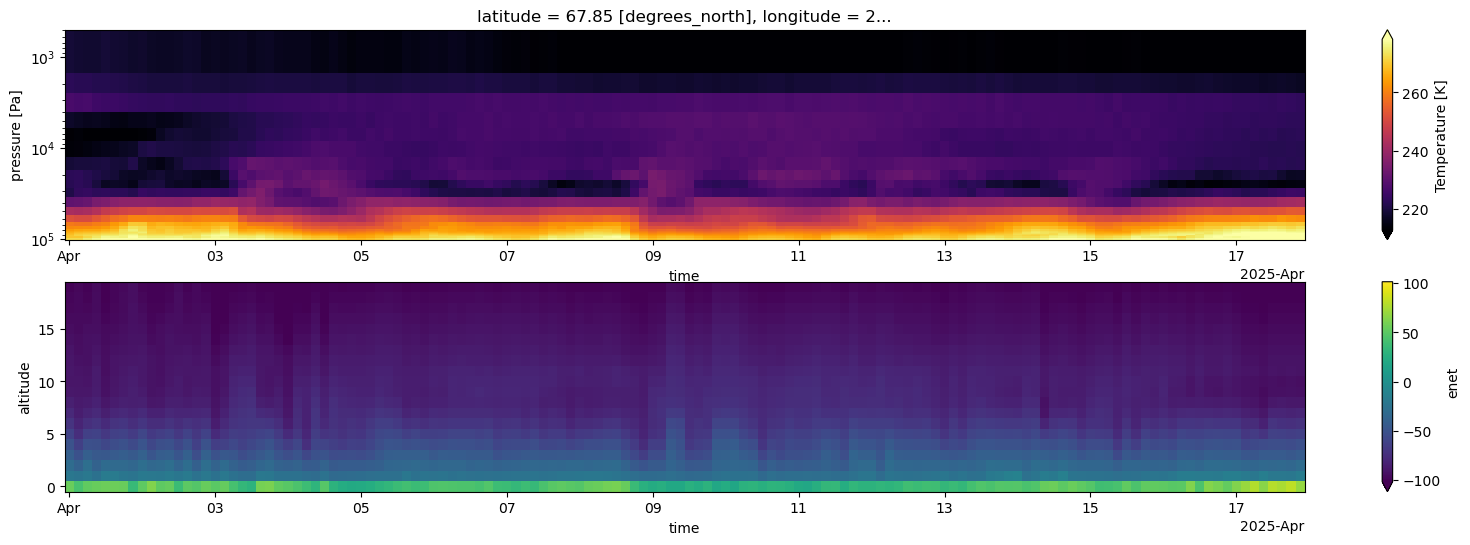

In [79]:
fig, ax = plt.subplots(2, 1, figsize=(20, 6))

#change the prop cycle
ax[0].set_prop_cycle(plt.cycler(color=plt.cm.viridis(np.linspace(0, 1, N_timesteps))))
ax[1].set_prop_cycle(plt.cycler(color=plt.cm.viridis(np.linspace(0, 1, N_timesteps))))

ds_sim.enet.plot(
    x='time',
    y='altitude',
    ax=ax[1],
    cmap='viridis',
    robust=True

)

ds_kiruna_to_sim['altitude'] = ds_kiruna['z'] / 9.81 / 1e3
ds_kiruna_to_sim.assign_coords(altitude=ds_kiruna_to_sim['z'])

ds_kiruna_to_sim.t.plot.pcolormesh(
    x='valid_time',
    ax=ax[0],
    y='pressure_level',
    cmap='inferno',
    robust=True,
    yincrease=False
)
ax[0].set_yscale('log')
